In [1]:
!pip install -q faiss-cpu beir sentence-transformers transformers \
    rouge-score sacrebleu bert-score evaluate \
    matplotlib seaborn pandas scikit-learn tqdm scipy --upgrade

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 59.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 90.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 81.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 M

In [2]:
import os, time, random, gc, warnings, math
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, faiss
from tqdm.auto import tqdm

import torch
from sklearn.decomposition import PCA
from sklearn.utils.extmath import randomized_svd
from sklearn.random_projection import GaussianRandomProjection
from sklearn.preprocessing import normalize
from sklearn.metrics import ndcg_score
from scipy.optimize import curve_fit

from beir import util
from beir.datasets.data_loader import GenericDataLoader
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM

from rouge_score import rouge_scorer
from bert_score import score as bert_score

from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("Set2")
pd.options.display.float_format = "{:.4f}".format
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RNG    = np.random.default_rng(42)


2025-05-13 11:08:49.085781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747134529.295944      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747134529.354390      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
DATA_DIR = Path("datasets")
DATASET_URLS = {
    "scifact"     : "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip",
    "scidocs"  : "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scidocs.zip",
    "fiqa" : "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip",
    "nfcorpus"       : "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/nfcorpus.zip"
}


In [4]:
#Add Your Datasets to DATASET_LIST
DATASET_LIST = ["scifact","scidocs", "fiqa", "nfcorpus"]

In [5]:
def load_dataset(name, split="test"):
    url = DATASET_URLS[name]
    path = util.download_and_unzip(url, str(DATA_DIR))
    corpus, queries, qrels = GenericDataLoader(path).load(split=split)
    doc_ids = sorted(corpus.keys()); query_ids = sorted(queries.keys())
    docs   = [corpus[d]["text"] for d in doc_ids]
    qtexts = [queries[q] for q in query_ids]
    relevant=[]
    for qid in query_ids:
        idx=[doc_ids.index(d) for d in qrels.get(qid,{}) if d in doc_ids]
        relevant.append(np.asarray(idx,dtype=int))
    return {"docs":docs,"queries":qtexts,"relevant":relevant}

In [6]:
#Add Your Embedding Models to EMBED_MODELS
EMBED_MODELS = {
    "mpnet"  : "sentence-transformers/all-mpnet-base-v2"
}

embedders = {k: SentenceTransformer(v, device=DEVICE) for k,v in EMBED_MODELS.items()}
precomputed={}
for ds in DATASET_LIST:
    print(f"Embedding {ds}")
    data = load_dataset(ds)
    precomputed[ds] = {"docs":data["docs"],"queries":data["queries"],
                       "relevant":data["relevant"],"embs":{}}
    for eb, mdl in embedders.items():
        d_emb = mdl.encode(data["docs"], batch_size=128, show_progress_bar=False, convert_to_numpy=True)
        q_emb = mdl.encode(data["queries"], batch_size=128, show_progress_bar=False, convert_to_numpy=True)
        
        mu = d_emb.mean(axis = 0, keepdims = True)
        d_emb = d_emb - mu
        q_emb = q_emb - mu
        d_emb = normalize(d_emb); q_emb = normalize(q_emb)
        precomputed[ds]["embs"][eb] = {"doc_emb":d_emb,"qry_emb":q_emb}
        print(f"{eb}: {d_emb.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

  0%|          | 0/57638 [00:00<?, ?it/s]

  mpnet: (57638, 768)
Embedding nfcorpus


datasets/nfcorpus.zip:   0%|          | 0.00/2.34M [00:00<?, ?iB/s]

  0%|          | 0/3633 [00:00<?, ?it/s]

  mpnet: (3633, 768)


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_topk_cosine(query_emb, doc_emb, k=10):
    scores = cosine_similarity(query_emb, doc_emb)
    return np.argsort(-scores, axis=1)[:, :k]

def faiss_lsh_index(doc_emb, n_bits=None):
    d = doc_emb.shape[1]
    if n_bits is None:
        n_bits = d * 2  # more bits = better accuracy
    index = faiss.IndexLSH(d, n_bits)
    faiss.normalize_L2(doc_emb)
    index.add(doc_emb)
    return index

def retrieve_lsh(index, query_emb, k=10):
    faiss.normalize_L2(query_emb)
    _, I = index.search(query_emb, k)
    return I

def faiss_pq_index(doc_emb, m=16, nbits=8):
    d = doc_emb.shape[1]
    quantizer = faiss.IndexFlatL2(d)
    index = faiss.IndexPQ(d, m, nbits)
    index.train(doc_emb)
    index.add(doc_emb)
    return index

def retrieve_pq(index, query_emb, k=10):
    _, I = index.search(query_emb, k)
    return I

def recall_at_k(pred_indices, ground_truth, k=10):
    correct = 0
    for i in range(len(ground_truth)):
        gt_set = set(ground_truth[i])
        pred_set = set(pred_indices[i][:k])
        correct += len(gt_set & pred_set)
    return correct / (len(ground_truth) * k)

def cosine_distortion(orig_emb, comp_emb, n_samples=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = orig_emb.shape[0]
    idx_i = rng.integers(0, n, size=n_samples)
    idx_j = rng.integers(0, n, size=n_samples)
    orig = normalize(orig_emb)
    comp = normalize(comp_emb)
    cos_orig = np.sum(orig[idx_i] * orig[idx_j], axis=1)
    cos_comp = np.sum(comp[idx_i] * comp[idx_j], axis=1)
    return np.mean(np.abs(cos_orig - cos_comp))

def knn_overlap_at_k(orig_emb, comp_emb, k=10):
    from sklearn.metrics.pairwise import cosine_similarity
    sim_orig = cosine_similarity(orig_emb)
    sim_comp = cosine_similarity(comp_emb)
    overlap = []
    for i in range(sim_orig.shape[0]):
        orig_top = np.argsort(-sim_orig[i])[:k]
        comp_top = np.argsort(-sim_comp[i])[:k]
        overlap.append(len(set(orig_top) & set(comp_top)) / k)
    return np.mean(overlap)

def precision_at_k(pred_indices, gt_indices, k=10):
    precisions = []
    for preds, gts in zip(pred_indices, gt_indices):
        precisions.append(len(set(preds[:k]) & set(gts)) / k)
    return np.mean(precisions)

def mrr_at_k(pred_indices, gt_indices, k=10):
    rr = []
    for preds, gts in zip(pred_indices, gt_indices):
        rank = next((i+1 for i,doc in enumerate(preds[:k]) if doc in gts), None)
        rr.append(1.0/rank if rank else 0.0)
    return np.mean(rr)

In [8]:
def randsvd_Q(M, k, p=10, q=2, device=None):
    if device is None:
        device = M.device

    m, n = M.shape
    l = k + p

    Omega = torch.randn(n, l, device=device) 
    Y = M @ Omega 
    for _ in range(q): 
        Y = M @ (M.T @ Y)

    Q, _ = torch.linalg.qr(Y, mode='reduced')

    return Q

def randsvd_decompose_and_project(docs_np, queries_np, k, p=10, q=2, device='cuda'):
    M = torch.from_numpy(docs_np).to(device)  
    
    Qr = randsvd_Q(M.T, k, p=p, q=q, device=device)
    
    Qr_k = Qr[:, :k]  # (d, k)
    
    docs_rsvd = (M @ Qr_k).cpu().numpy()          
    queries_rsvd = queries_np @ Qr_k.cpu().numpy()  
    
    return docs_rsvd, queries_rsvd

In [35]:
import numpy as np
import pandas as pd
import faiss
from sklearn.preprocessing import normalize

def noise_robustness_experiment(docs, queries, gt_top, Qk, noise_levels, k=10):

    d = docs.shape[1]
    #LSH 
    lsh_idx = faiss.IndexLSH(d, d * 4)
    lsh_idx.add(docs.astype('float32'))
    #PQ
    pq_idx = faiss.IndexPQ(d, 64, 8)
    pq_idx.train(docs.astype('float32'))
    pq_idx.add(docs.astype('float32'))
    #RandSVD
    docs_rsvd = normalize(docs @ Qk)
    
    #Baseline 
    preds_vanilla = retrieve_topk_cosine(queries, docs, k)
    recall_baseline = recall_at_k(preds_vanilla, gt_top, k)
    
    methods = ['LSH', 'PQ', 'RandSVD']
    results = {m: [] for m in methods}
    
    rng = np.random.default_rng(42)
    for sigma in noise_levels:
        #Noise
        noisy_q = queries + sigma * rng.standard_normal(queries.shape)
        noisy_q = normalize(noisy_q)              
        noisy_q = noisy_q.astype("float32")       
        noisy_q = np.ascontiguousarray(noisy_q) 
        
        #LSH
        preds_lsh = retrieve_lsh(lsh_idx, noisy_q, k)
        recall_lsh = recall_at_k(preds_lsh, gt_top, k)
        results['LSH'].append(recall_baseline - recall_lsh)
        
        #PQ
        preds_pq = retrieve_pq(pq_idx, noisy_q, k)
        recall_pq = recall_at_k(preds_pq, gt_top, k)
        results['PQ'].append(recall_baseline - recall_pq)
        
        #RandSVD 
        q_rsvd = normalize(noisy_q @ Qk)
        preds_rsvd = retrieve_topk_cosine(q_rsvd, docs_rsvd, k)
        recall_rsvd = recall_at_k(preds_rsvd, gt_top, k)
        results['RandSVD'].append(recall_baseline - recall_rsvd)
    
    df = pd.DataFrame(results, index=noise_levels)
    df.index.name = 'Noise Std'
    return df


docs = precomputed['scidocs']['embs']['mpnet']['doc_emb']
queries = precomputed['scifact']['embs']['mpnet']['qry_emb']
gt_top = retrieve_topk_cosine(queries, docs, k=10)

import torch
k_rsvd, p, q_iters = 256, 10, 2
D_t = torch.from_numpy(docs).to('cuda' if torch.cuda.is_available() else 'cpu')
Qr = randsvd_Q(D_t.T, k_rsvd, p=p, q=q_iters, device=D_t.device)
Qk = Qr[:, :k_rsvd].cpu().numpy()

noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5]
df_noise = noise_robustness_experiment(docs, queries, gt_top, Qk, noise_levels, k=10)
df_noise


,LSH,PQ,RandSVD
Noise Std,,,
0.0100,0.2267,0.3490,0.1790
0.0500,0.5103,0.6030,0.4573
0.1000,0.8163,0.8463,0.7827
0.2000,0.9737,0.9687,0.9633
0.5000,0.9977,0.9937,0.9963


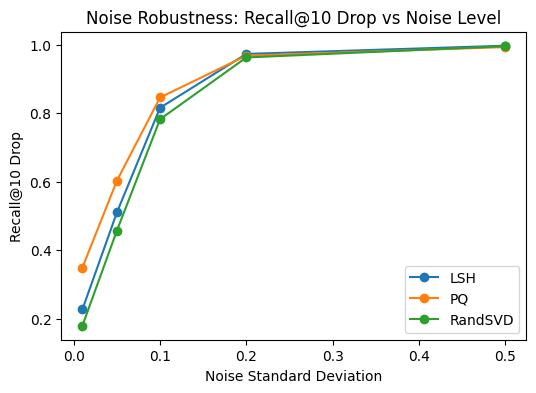

In [37]:
plt.figure(figsize=(6,4))
for method in df_noise.columns:
    plt.plot(df_noise.index, df_noise[method], marker='o', label=method)

plt.xlabel("Noise Standard Deviation")
plt.ylabel("Recall@10 Drop")
plt.title("Noise Robustness: Recall@10 Drop vs Noise Level")
plt.legend()
plt.savefig('noise_robustness.png')
plt.show()